In [2]:
import sys
import torch

sys.path.insert(0, 'src')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cpu


---
## Section 1 - VGG16 Architecture

In [3]:
from utils import load_vgg16, load_imagenet_classes
from section1 import count_parameters, classify, get_activation_maps, show_all_maps, show_activation_maps

vgg16 = load_vgg16()
classes = load_imagenet_classes()

In [4]:
# Q1: Parameter count
count_parameters(vgg16)

# Q2: Last layer output
print(f"  {vgg16.classifier[6]} -> {vgg16.classifier[6].out_features} outputs")

  Total: 138,357,544 | Conv: 14,714,688 (10.6%) | FC: 123,642,856 (89.4%)
  Linear(in_features=4096, out_features=1000, bias=True) -> 1000 outputs


In [5]:
# Q3: Classify images
import glob
for p in sorted(glob.glob('images/*.jpg')): classify(p, vgg16, classes)

First conv: (64, 224, 224)


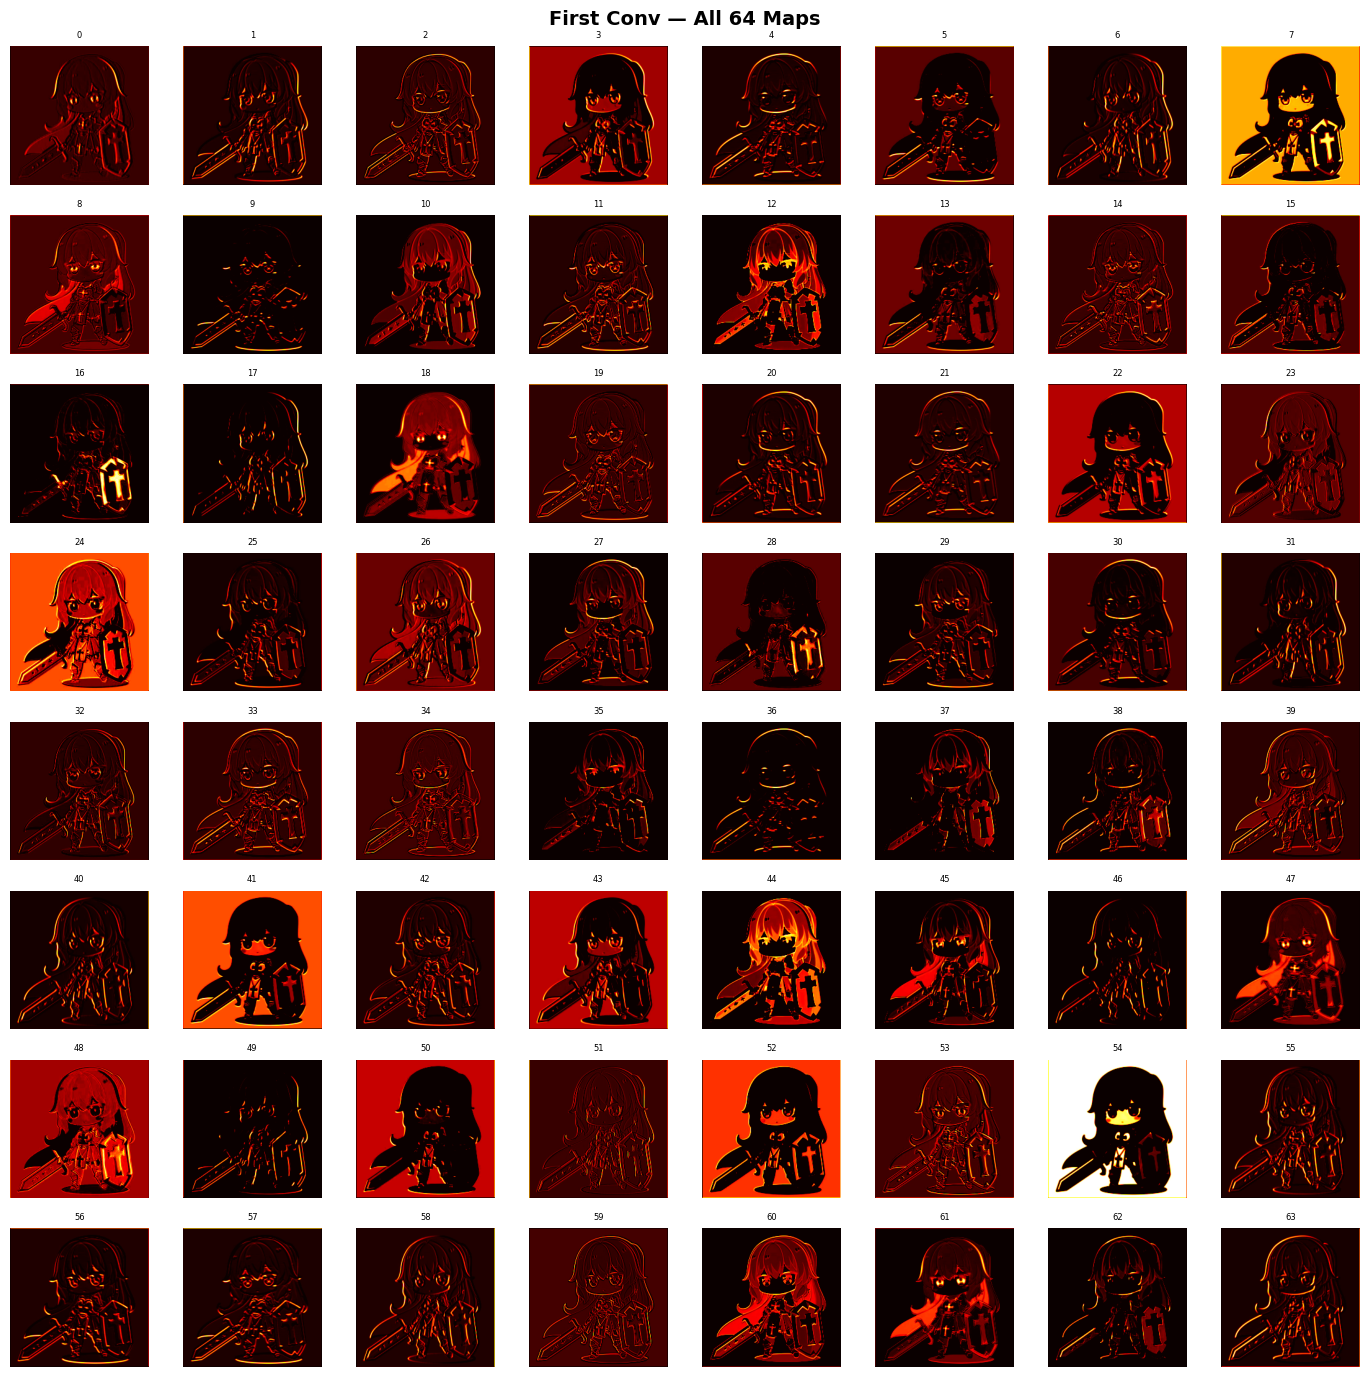

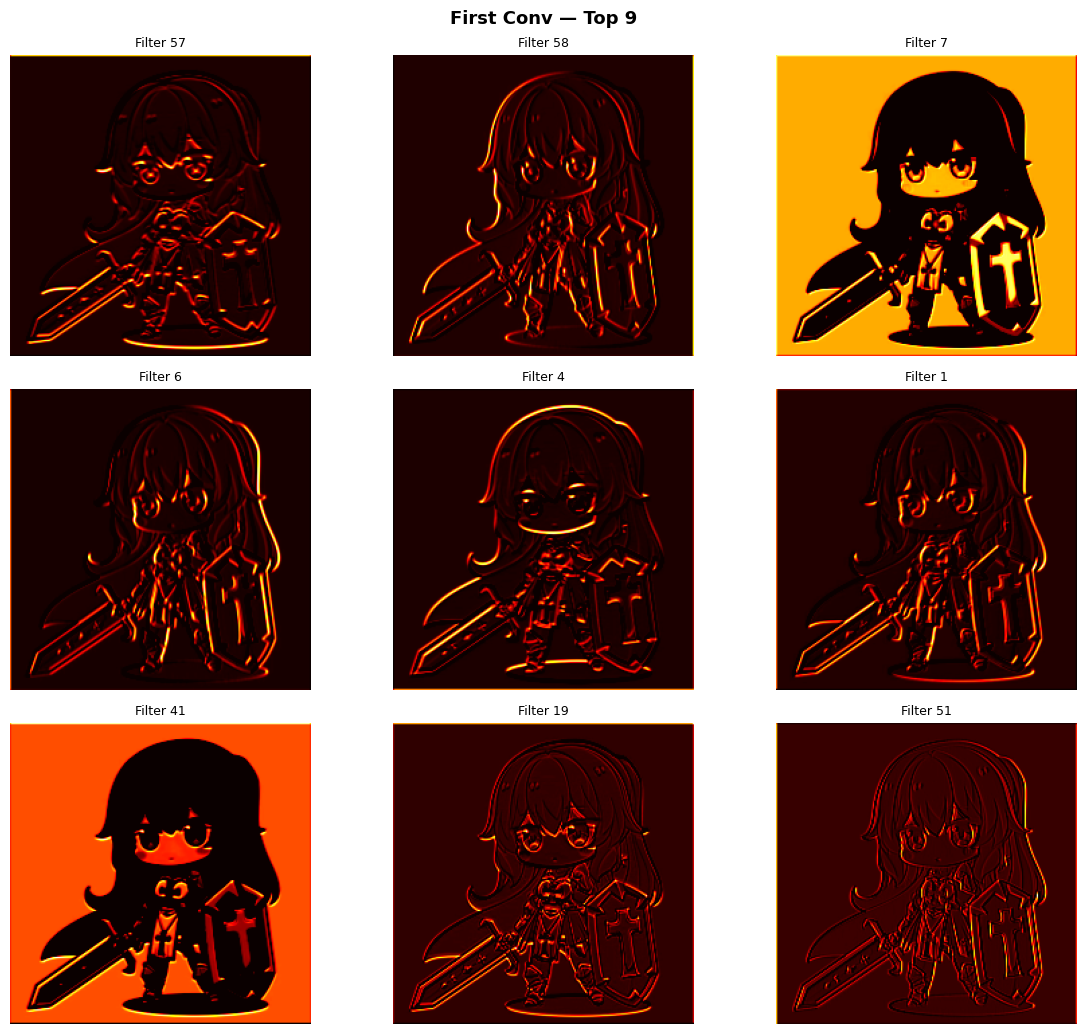

Deep layer: (512, 14, 14)


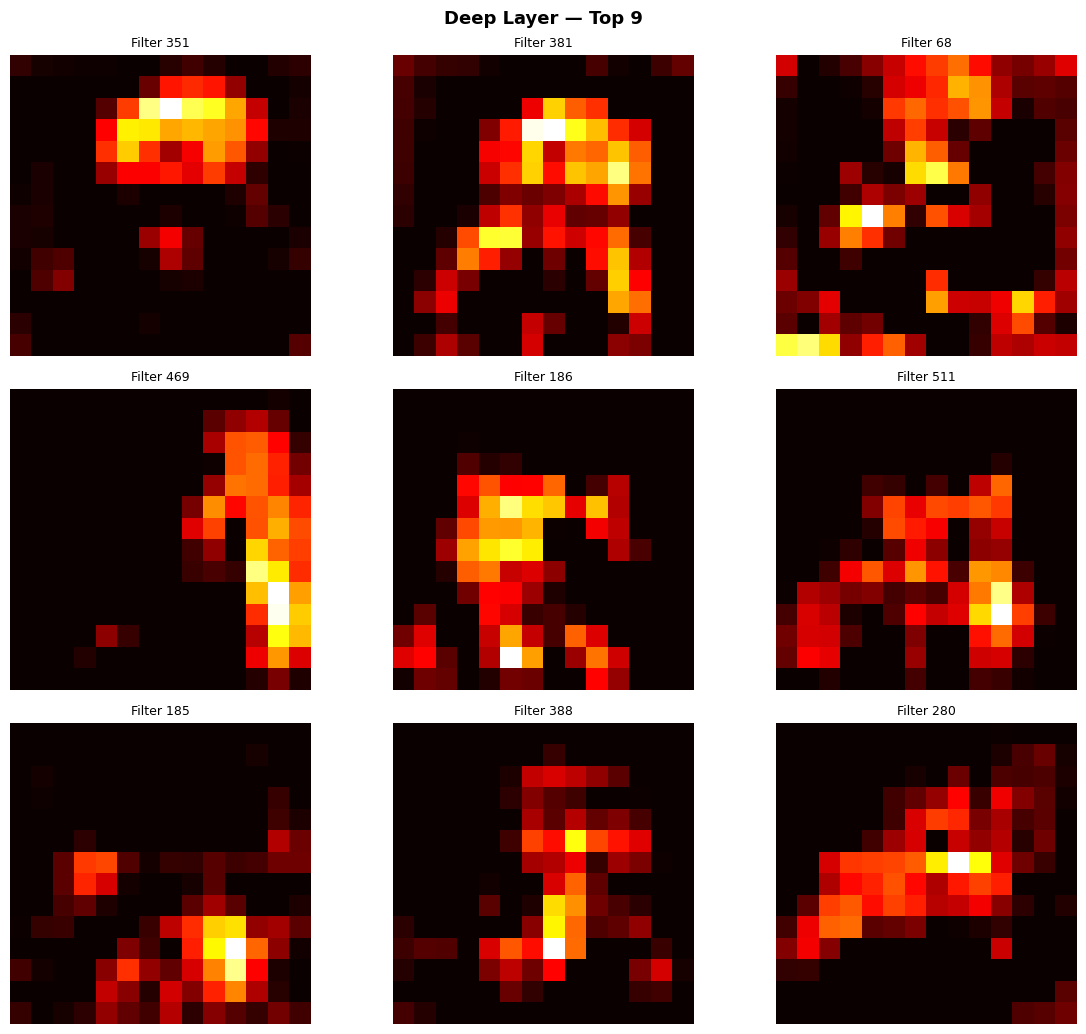

In [6]:
# Q4: Activation maps
img = 'data/test/paladin.jpg'

acts0 = get_activation_maps(vgg16, img, layer_index=0)
print(f"First conv: {acts0.shape}")
show_all_maps(acts0, 'First Conv — All 64 Maps')
show_activation_maps(acts0, 9, 'First Conv — Top 9')

acts_deep = get_activation_maps(vgg16, img, layer_index=24)
print(f"Deep layer: {acts_deep.shape}")
show_activation_maps(acts_deep, 9, 'Deep Layer — Top 9')

---
## Section 2 - Transfer Learning on 15-Scene

In [7]:
from section2 import VGG16relu7, load_15scene, extract_and_normalize, train_and_eval, plot_confusion

In [8]:
tr_p, y_tr, te_p, y_te, names = load_15scene('data/15-Scene')

  Downloading...
  Downloading...
  Extracting .rar...


CalledProcessError: Command '['c:\\Users\\giuse\\AppData\\Local\\Programs\\Python\\Python310\\python.exe', '-m', 'pip', 'install', '-q', 'unrar-cffi']' returned non-zero exit status 1.

In [8]:
# 2.2 Feature extraction
ext = VGG16relu7(vgg16); ext.eval()

print("Train features:")
X_train = extract_and_normalize(tr_p, ext, device)
print(f"  shape: {X_train.shape}")

print("Test features:")
X_test = extract_and_normalize(te_p, ext, device)
print(f"  shape: {X_test.shape}")

Train features:


ValueError: need at least one array to concatenate

In [ ]:
# 2.3 SVM
svm, acc, y_pred = train_and_eval(X_train, y_tr, X_test, y_te, C=1.0, class_names=names)
plot_confusion(y_te, y_pred, names, f'relu7 + SVM — {acc:.2%}')

---
## Section 2.4 — Going Further

In [ ]:
from section2_4 import experiment_layers, experiment_C, experiment_resnet, experiment_finetune, experiment_pca

In [ ]:
# 2.4.1 Layer comparison
layer_res = experiment_layers(tr_p, y_tr, te_p, y_te, device)

In [ ]:
# 2.4.2 Tune C
best_C = experiment_C(X_train, y_tr, X_test, y_te)

In [ ]:
# 2.4.3 ResNet50
resnet_acc = experiment_resnet(tr_p, y_tr, te_p, y_te, device, best_C)
print(f"  VGG16: {acc:.2%} vs ResNet50: {resnet_acc:.2%}")

In [ ]:
# 2.4.4 Fine-tune last layer
ft = experiment_finetune(tr_p, y_tr, te_p, y_te, n_classes=len(names), device=device)

In [ ]:
# 2.4.5 PCA
pca_res = experiment_pca(X_train, y_tr, X_test, y_te, C=best_C)